### AGGLOMERATIVE CLUSTERING

In [50]:
import numpy as np
import pandas as pd

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

##### Loading datasets

In [51]:
data = pd.read_csv("../../../data/preprocessed/preprocessed_dataset.csv")
y = data["expression"].astype("category").cat.codes

datasets = {
    "Scaled dataset": "../../../data/reduced/X_scaled.npy",
    "PCA dataset": "../../../data/reduced/X_pca.npy"
}

##### Agglomerative clustering

In [52]:
results = []

for dataset_name, X_data in datasets.items():
    X = np.load(X_data)

    # sampling to avoid O(n^2) explosion
    sample_size = 5000
    np.random.seed(42)
    sample_idx = np.random.choice(len(X), sample_size, replace=False)

    X = X[sample_idx]
    y_sample = y[sample_idx]

    k = 4
    model = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = model.fit_predict(X)

    row = {
        "Dataset": dataset_name,
        "Algorithm": "Agglomerative",
        "K": k,
        "Silhouette": silhouette_score(X, labels, sample_size=3000),
        "Davies_Bouldin": davies_bouldin_score(X, labels),
        "ARI": adjusted_rand_score(y_sample, labels),
        "NMI": normalized_mutual_info_score(y_sample, labels)
    }
    results.append(row)

    if dataset_name == "PCA dataset":
        tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=500)
        X_tsne = tsne.fit_transform(X)

        plt.figure(figsize=(6,5))
        plt.scatter(X_tsne[:,0], X_tsne[:,1], c=labels, cmap="tab10", s=5)
        plt.title("Agglomerative Clustering (t-SNE visualization)")
        plt.tight_layout()
        plt.savefig(f"../../../results/ahc/TSNE_{dataset_name}.png", dpi=200)
        plt.close()
        # plt.show()

        plt.figure(figsize=(6,5))
        plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_sample, s=5, cmap="tab10")
        plt.title(f"True classes TSNE ({dataset_name})")
        plt.tight_layout()
        plt.savefig(f"../../../results/ahc/trueTSNE_{dataset_name}.png", dpi=200)
        plt.close()
        # plt.show()

results_df = pd.DataFrame(results)
results_df = results_df.round({
    "Silhouette": 4,
    "Davies_Bouldin": 4,
    "ARI": 4,
    "NMI": 4
})

results_df.to_csv("../../../results/ahc/ahc_results_summary.csv", index=False)
print(results_df)

          Dataset      Algorithm  K  Silhouette  Davies_Bouldin     ARI    NMI
0  Scaled dataset  Agglomerative  4      0.2697          1.4987  0.0481  0.132
1     PCA dataset  Agglomerative  4      0.3017          1.4683  0.0429  0.126


##### Ground truth vs clusters graphics

In [53]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

ax[0].scatter(X_tsne[:,0], X_tsne[:,1], c=y_sample, s=5, cmap="tab10")
ax[0].set_title("True classes")

ax[1].scatter(X_tsne[:,0], X_tsne[:,1], c=labels, s=5, cmap="tab10")
ax[1].set_title("Agglomerative clusters")

plt.tight_layout()

plt.savefig("../../../results/ahc/comparison.png", dpi=200)
plt.close()
# plt.show()

##### Confusion heatmap

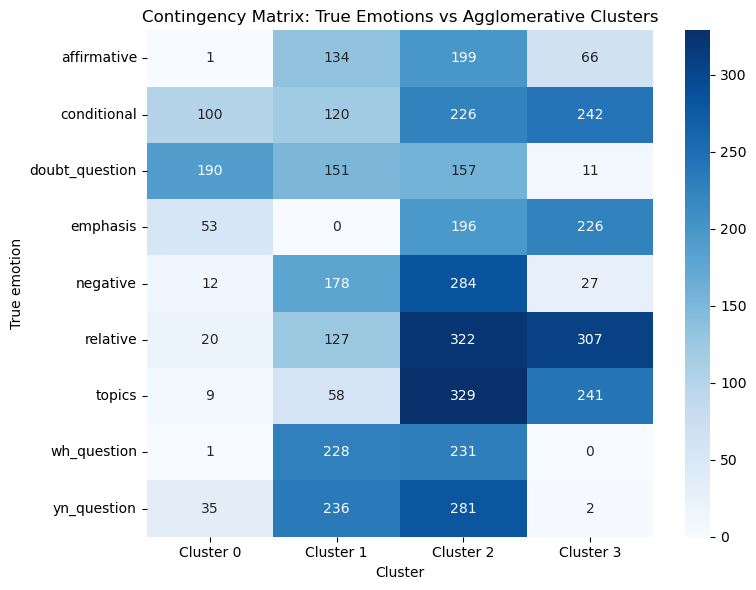

In [54]:
from sklearn.metrics.cluster import contingency_matrix
import seaborn as sns

emotion_names = data["expression"].astype("category").cat.categories
# print(emotion_names)

cm = contingency_matrix(y_sample, labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    yticklabels=emotion_names,
    xticklabels=[f"Cluster {i}" for i in range(cm.shape[1])]
)
plt.title("Contingency Matrix: True Emotions vs Agglomerative Clusters")
plt.xlabel("Cluster")
plt.ylabel("True emotion")
plt.tight_layout()
plt.savefig("../../../results/ahc/contingency_matrix_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close()

#The contingency heatmap shows that the clusters contain mixed emotion categories. This indicates 
# that the hierarchical clustering algorithm captures visual similarities between facial expressions 
# rather than strictly separating semantic emotion labels.

In [55]:
# To interpret the clusters, we analyzed the distribution of grammatical facial expression labels 
# within each cluster.
# The results show that clusters tend to contain mixtures of several expression types, suggesting 
# that the clustering algorithm captures similarities in facial movement patterns rather than 
# strictly separating grammatical categories.
for cluster_id in range(cm.shape[1]):
    cluster_counts = cm[:, cluster_id]
    dominant_class_idx = np.argmax(cluster_counts)
    dominant_class = emotion_names[dominant_class_idx]
    purity = cluster_counts[dominant_class_idx] / np.sum(cluster_counts)
    print(
        f"Cluster {cluster_id} → mostly '{dominant_class}' "
        f"({purity:.2%} of samples)"
    )

Cluster 0 → mostly 'doubt_question' (45.13% of samples)
Cluster 1 → mostly 'yn_question' (19.16% of samples)
Cluster 2 → mostly 'topics' (14.79% of samples)
Cluster 3 → mostly 'relative' (27.36% of samples)


##### Dendrogram

In [56]:
from scipy.cluster.hierarchy import linkage, dendrogram
X = np.load("../../../data/reduced/X_pca.npy")


# Koristili smo uzorak od 300 nasumičnih tačaka da bismo izbegli preveliku složenost dendrograma, 
# koji može biti teško čitljiv sa velikim brojem uzoraka.
np.random.seed(42)
sample_size = 300
sample_idx = np.random.choice(len(X), sample_size, replace=False)
X_sample = X[sample_idx]

Z = linkage(X_sample, method="ward")

plt.figure(figsize=(16, 7))
dendrogram(
    Z,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=45,
    leaf_font_size=10,
    show_contracted=True
)
plt.title("Truncated Dendrogram (last 30 merges)")
plt.xlabel("Cluster groups")
plt.ylabel("Distance")
plt.grid(True)
plt.tight_layout()
plt.savefig("../../../results/ahc/dendrogram.png", dpi=200)
plt.close()
# plt.show()

##### To estimate the optimal number of clusters suggested by the hierarchical structure, the dendrogram was analyzed using silhouette scores for different cut levels. The best score was obtained for k = X, which indicates the most natural partitioning of the data.

In [57]:
from scipy.cluster.hierarchy import fcluster
best_k = 0
best_score = -1

for k in range(2, 10):
    labels = fcluster(Z, t=k, criterion="maxclust")
    
    score = silhouette_score(X_sample, labels)
    
    if score > best_score:
        best_score = score
        best_k = k

print("Best number of clusters:", best_k)

Best number of clusters: 4


##### Graph: Silhouette vs Number of Clusters

In [58]:
scores = []
ks = range(2, 10)

for k in ks:
    labels = fcluster(Z, t=k, criterion="maxclust")
    score = silhouette_score(X_sample, labels)
    scores.append(score)

plt.plot(ks, scores, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.title("Optimal number of clusters from hierarchical clustering")
plt.tight_layout()
plt.savefig("../../../results/ahc/optimal_clusters.png", dpi=200)
plt.close()
# plt.show()